In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('retail_store_inventory.csv')

# Preview data
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
# Convert Date column (change column name if needed)
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
# Sort by date
df = df.sort_values('Date')

In [27]:
# Handle missing values
df.fillna(method='ffill', inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_15772\3603679448.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_15772\3603679448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(method='ffill', inplace=True)


In [28]:
# Remove duplicates
df = df.drop_duplicates()


In [9]:
# Detect outliers (IQR method)
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Units Sold'] >= Q1 - 1.5 * IQR) & (df['Units Sold'] <= Q3 + 1.5 * IQR)]

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer


In [10]:
# Summary statistics
df.describe()


,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,72385,72385.000000,72385.000000,72385.000000,72385.000000,72385.000000,72385.000000,72385.000000,72385.000000
mean,2023-01-01 01:30:15.442425856,272.453229,133.300808,109.990647,138.333292,55.155914,10.005457,0.497617,55.165655
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,161.000000,48.000000,65.000000,53.230000,32.660000,5.000000,0.000000,32.690000
50%,2023-01-01 00:00:00,271.000000,106.000000,110.000000,111.570000,55.080000,10.000000,0.000000,55.040000
75%,2023-07-03 00:00:00,384.000000,199.000000,155.000000,204.350000,77.890000,15.000000,1.000000,77.860000
max,2024-01-01 00:00:00,500.000000,434.000000,200.000000,453.150000,100.000000,20.000000,1.000000,104.940000
std,NaN,128.978742,104.665077,52.271512,105.021337,26.022266,7.084558,0.499998,26.192194


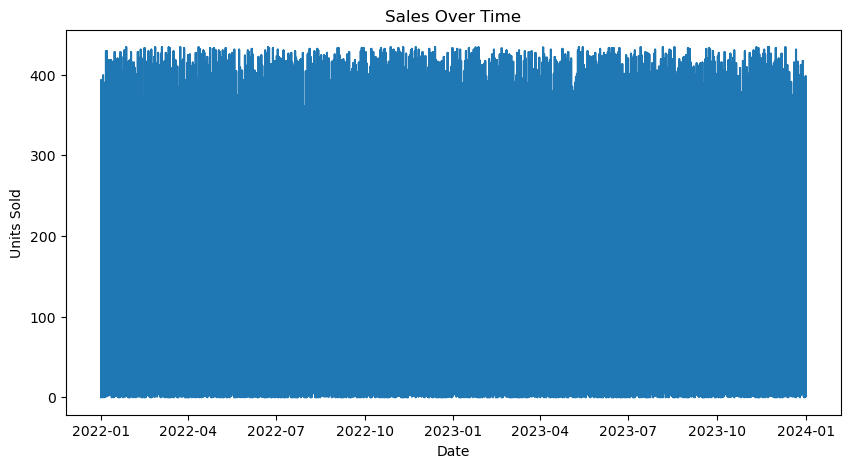

In [13]:
# Plot sales over time
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Units Sold'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_15772\251460056.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Date')['Units Sold'].resample('M').mean().plot(figsize=(10,5))


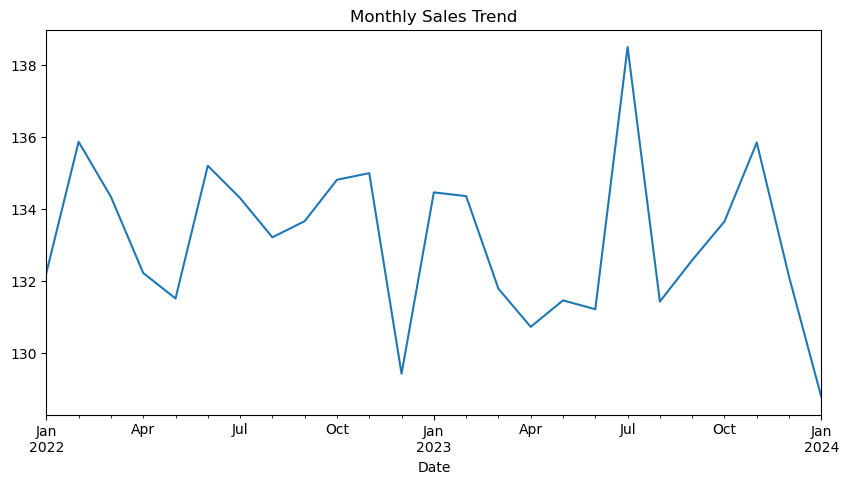

In [14]:
# Monthly trend
df.set_index('Date')['Units Sold'].resample('M').mean().plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

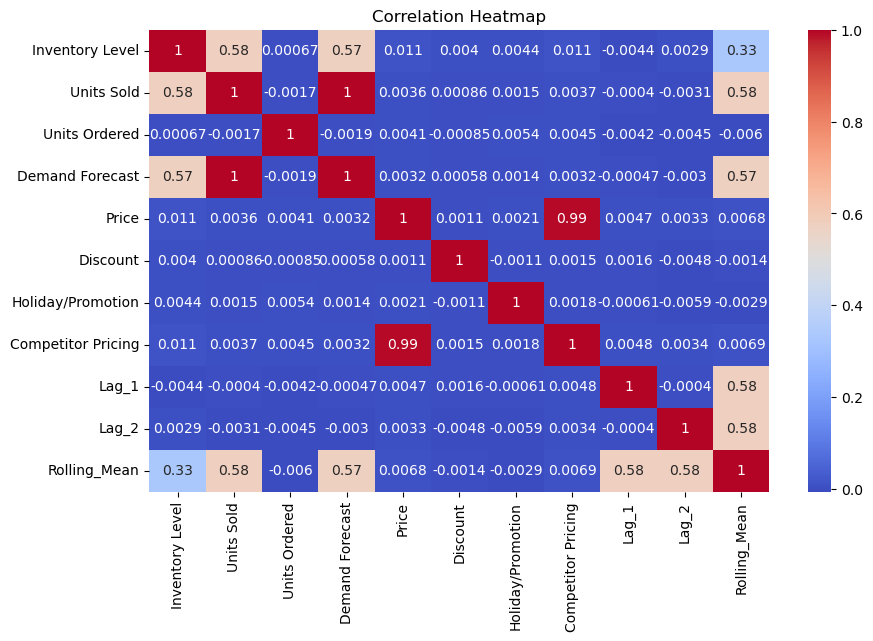

In [29]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek


C:\Users\hp\AppData\Local\Temp\ipykernel_15772\3680442711.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Date'].dt.year
C:\Users\hp\AppData\Local\Temp\ipykernel_15772\3680442711.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month'] = df['Date'].dt.month
C:\Users\hp\AppData\Local\Temp\ipykernel_15772\3680442711.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

In [17]:
# Lag features
df['Lag_1'] = df['Units Sold'].shift(1)
df['Lag_2'] = df['Units Sold'].shift(2)


C:\Users\hp\AppData\Local\Temp\ipykernel_15772\128327609.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lag_1'] = df['Units Sold'].shift(1)
C:\Users\hp\AppData\Local\Temp\ipykernel_15772\128327609.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Lag_2'] = df['Units Sold'].shift(2)


In [18]:
# Rolling mean
df['Rolling_Mean'] = df['Units Sold'].rolling(window=3).mean()

# Drop NA from lag features
df = df.dropna()

df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_15772\2889833798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rolling_Mean'] = df['Units Sold'].rolling(window=3).mean()


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,Lag_1,Lag_2,Rolling_Mean
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,...,1,18.56,Spring,2022,1,1,5,56.0,127.0,64.000000
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,...,1,57.76,Spring,2022,1,1,5,9.0,56.0,37.000000
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,...,0,37.15,Summer,2022,1,1,5,46.0,9.0,53.000000
68,2022-01-01,S004,P0009,Furniture,North,63,40,73,51.78,59.23,...,1,61.10,Summer,2022,1,1,5,104.0,46.0,63.333333
67,2022-01-01,S004,P0008,Furniture,South,250,51,137,54.98,85.88,...,1,86.14,Winter,2022,1,1,5,40.0,104.0,65.000000


In [19]:
from sklearn.model_selection import train_test_split

# Features and target
X = df[['Year','Month','Day','DayOfWeek','Lag_1','Lag_2','Rolling_Mean']]
y = df['Units Sold']

# Train-test split (time series style)
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [22]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA (p,d,q)
arima_model = ARIMA(df['Units Sold'], order=(5,1,0))
arima_result = arima_model.fit()

arima_pred = arima_result.forecast(steps=len(y_test))

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name} RMSE:", rmse)
    print(f"{model_name} MAE:", mae)
    print("------")

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, arima_pred, "ARIMA")

Linear Regression RMSE: 1.0475093102829747e-13
Linear Regression MAE: 8.185517327565486e-14
------
Random Forest RMSE: 4.41458787689355
Random Forest MAE: 2.9959819023278307
------
ARIMA RMSE: 124.8422133836514
ARIMA MAE: 90.24584185912562
------


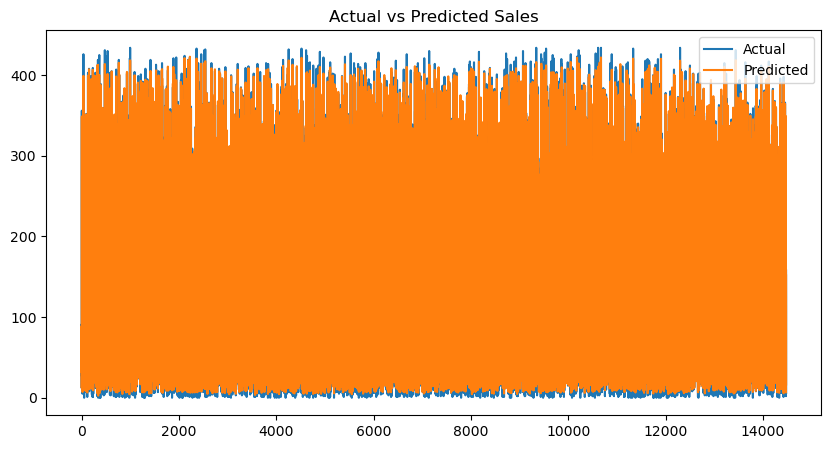

In [25]:
# Compare actual vs predicted
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(best_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [5,10,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None}


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE:", mae)
    print(f"{name} R2:", r2)
    print("------")

# Evaluate models
evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, arima_pred, "ARIMA")

# Best model evaluation
best_pred = best_model.predict(X_test)
evaluate(y_test, best_pred, "Tuned Random Forest")

Linear Regression RMSE: 1.0475093102829747e-13
Linear Regression MAE: 8.185517327565486e-14
Linear Regression R2: 1.0
------
Random Forest RMSE: 4.41458787689355
Random Forest MAE: 2.9959819023278307
Random Forest R2: 0.9982038642017287
------
ARIMA RMSE: 124.8422133836514
ARIMA MAE: 90.24584185912562
ARIMA R2: -0.43642103340647864
------
Tuned Random Forest RMSE: 4.839285620389248
Tuned Random Forest MAE: 3.234808025854554
Tuned Random Forest R2: 0.9978416526073819
------


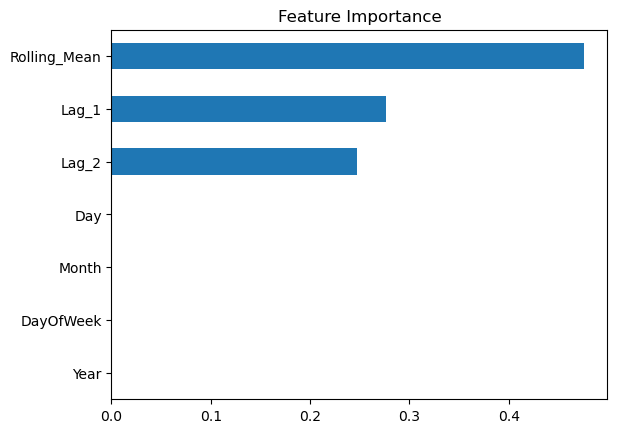

In [32]:
importance = best_model.feature_importances_
features = X.columns

pd.Series(importance, index=features).sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

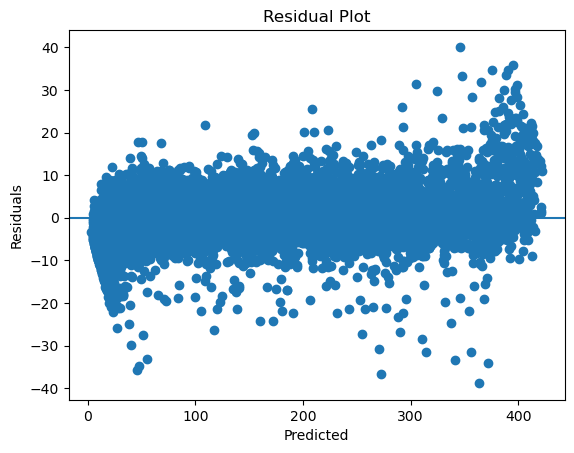

In [33]:
residuals = y_test - best_pred

plt.scatter(best_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [34]:
import joblib

joblib.dump(best_model, 'sales_model.pkl')
print("Model saved!")

Model saved!


In [35]:
model = joblib.load('sales_model.pkl')
model.predict(X_test.head())

array([ 33.40599007,  88.63283853,  56.26008001,  11.98753863,
       279.52432905])